GLOBAL CONFIGS AND IMPORTS

In [1]:
import os
import joblib

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    classification_report,

    confusion_matrix,

    precision_recall_curve,

    average_precision_score,

    ConfusionMatrixDisplay,

    roc_auc_score,

    roc_curve,

    auc
)

from sklearn.preprocessing import label_binarize

ARRAY_PATH = "processed_arrays/"

MODEL_PATH = "models/"

IMAGE_PATH = "images/"

LOADING THE PREPROCESSED DATA

In [2]:
X_train = np.load(
    os.path.join(ARRAY_PATH, "X_train.npy"),
    allow_pickle=True
)

y_train = np.load(
    os.path.join(ARRAY_PATH, "y_train.npy"),
    allow_pickle=True
)

X_val = np.load(
    os.path.join(ARRAY_PATH, "X_val.npy"),
    allow_pickle=True
)

y_val = np.load(
    os.path.join(ARRAY_PATH, "y_val.npy"),
    allow_pickle=True
)

X_test = np.load(
    os.path.join(ARRAY_PATH, "X_test.npy"),
    allow_pickle=True
)

y_test = np.load(
    os.path.join(ARRAY_PATH, "y_test.npy"),
    allow_pickle=True
)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

print("Data Loaded")

Data Loaded


LOADING THE TRAINED MODELS

In [3]:
# RANDOM FOREST
rf_model = joblib.load(
    os.path.join(
        MODEL_PATH,
        "random_forest.joblib"
    )
)

# SVM
svm_model = joblib.load(
    os.path.join(
        MODEL_PATH,
        "svm_model.joblib"
    )
)

# XGBOOST
xgb_model = XGBClassifier()

xgb_model.load_model(
    os.path.join(
        MODEL_PATH,
        "xgboost_model.json"
    )
)

models = {

    "Random Forest": rf_model,

    "XGBoost": xgb_model,

    "SVM": svm_model
}

print("Models Loaded")

Models Loaded


MODEL EVALUATION FUNCTION DEFINITION

In [4]:
def get_probabilities(model, X_data):

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        if scores.ndim == 1:
            scores = np.vstack([-scores, scores]).T

        exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    raise ValueError("Model does not support probability or decision scores.")


def evaluate_model(model, X_data, y_data):

    predictions = model.predict(
        X_data
    )

    y_prob = get_probabilities(
        model,
        X_data
    )

    accuracy = accuracy_score(
        y_data,
        predictions
    )

    precision_weighted = precision_score(
        y_data,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_data,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_data,
        predictions,
        average="weighted",
        zero_division=0
    )

    precision_macro = precision_score(
        y_data,
        predictions,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_data,
        predictions,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_data,
        predictions,
        average="macro",
        zero_division=0
    )

    confusion_mat = confusion_matrix(
        y_data,
        predictions
    )

    report = classification_report(
        y_data,
        predictions,
        zero_division=0
    )

    return {

        "predictions": predictions,

        "probabilities": y_prob,

        "accuracy": accuracy,

        "precision_weighted": precision_weighted,

        "recall_weighted": recall_weighted,

        "f1_weighted": f1_weighted,

        "precision_macro": precision_macro,

        "recall_macro": recall_macro,

        "f1_macro": f1_macro,

        "confusion_matrix": confusion_mat,

        "classification_report": report
    }

EVALUATING ALL MODELS

In [5]:
results = {}

for model_name, model in models.items():

    print("=" * 60)

    print(model_name)

    print("=" * 60)

    evaluation = evaluate_model(
        model,
        X_test,
        y_test
    )

    results[model_name] = evaluation

    print(evaluation["classification_report"])


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      0.90      0.95        10
           2       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200

XGBoost
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        21
           1       1.00      0.90      0.95        10
           2       0.98      1.00      0.99       169

    accuracy                           0.98       200
   macro avg       0.99      0.93      0.96       200
weighted avg       0.99      0.98      0.98       200

SVM
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        21
           1       0.58      0.70      0.64        10
           2       0.99      0.96      0.97      

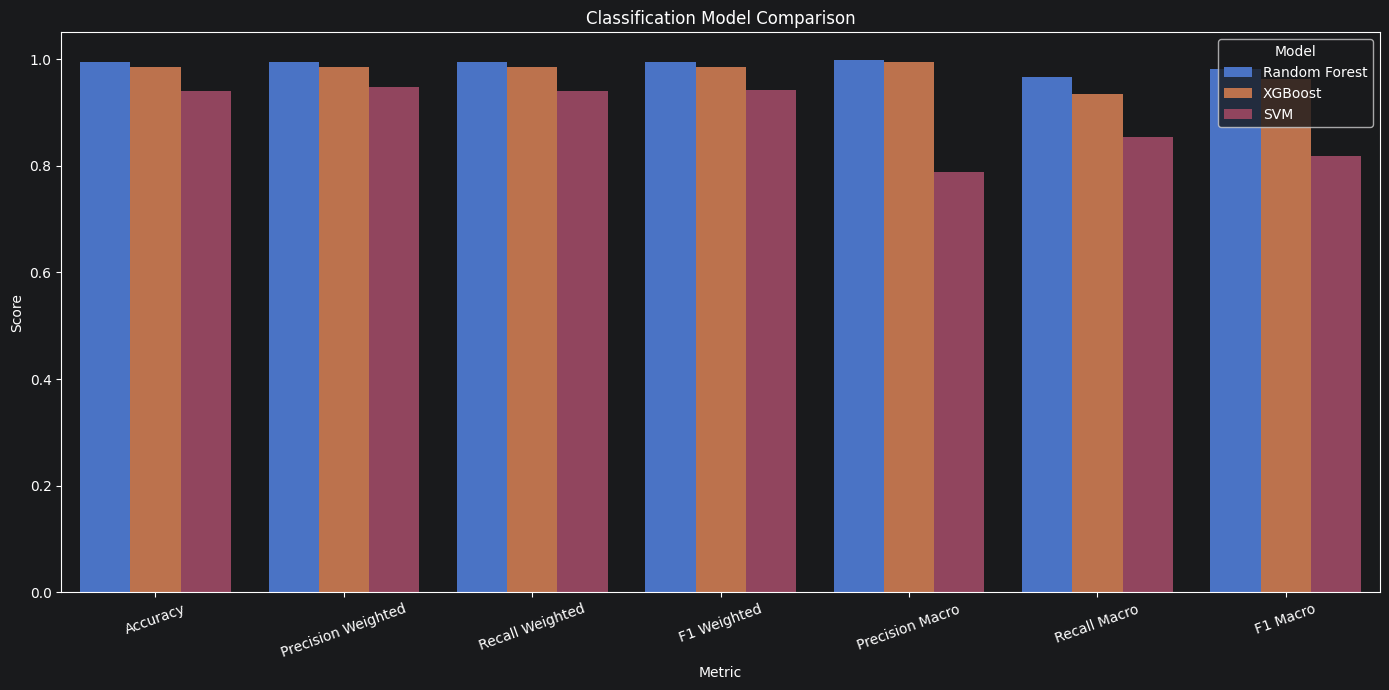

In [6]:
metrics_rows = []

for model_name, metrics in results.items():

    metrics_rows.append({

        "Model": model_name,

        "Accuracy": metrics["accuracy"],

        "Precision Weighted": metrics["precision_weighted"],

        "Recall Weighted": metrics["recall_weighted"],

        "F1 Weighted": metrics["f1_weighted"],

        "Precision Macro": metrics["precision_macro"],

        "Recall Macro": metrics["recall_macro"],

        "F1 Macro": metrics["f1_macro"]
    })

metrics_df = pd.DataFrame(
    metrics_rows
)

melted_metrics = metrics_df.melt(

    id_vars="Model",

    var_name="Metric",

    value_name="Score"
)

plt.figure(figsize=(14, 7))

sns.barplot(

    data=melted_metrics,

    x="Metric",

    y="Score",

    hue="Model"
)

plt.title("Classification Model Comparison")

plt.ylim(0, 1.05)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(

    os.path.join(
        IMAGE_PATH,
        "model_comparison.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

CONFUSION MATRICES

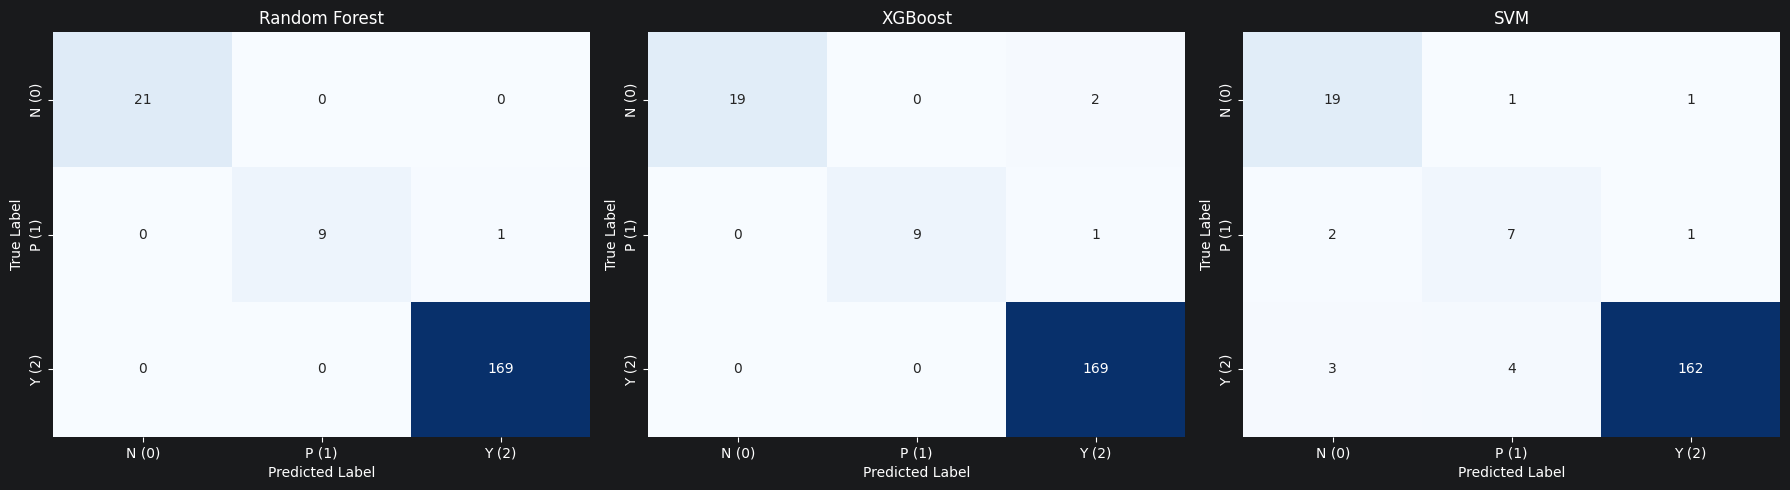

In [7]:
# CLASS LABELS
class_labels = [

    "N (0)",

    "P (1)",

    "Y (2)"
]

fig, axes = plt.subplots(

    1,
    3,

    figsize=(18, 5)
)

for ax, (model_name, metrics) in zip(
    axes,
    results.items()
):

    sns.heatmap(

        metrics["confusion_matrix"],

        annot=True,

        fmt="d",

        cmap="Blues",

        cbar=False,

        xticklabels=class_labels,

        yticklabels=class_labels,

        ax=ax
    )

    ax.set_title(model_name)

    ax.set_xlabel("Predicted Label")

    ax.set_ylabel("True Label")

plt.tight_layout()

plt.savefig(

    os.path.join(
        IMAGE_PATH,
        "confusion_matrices_labeled.png"
    ),

    dpi=300,

    bbox_inches="tight"
)

plt.show()

ROC AND PR CURVES

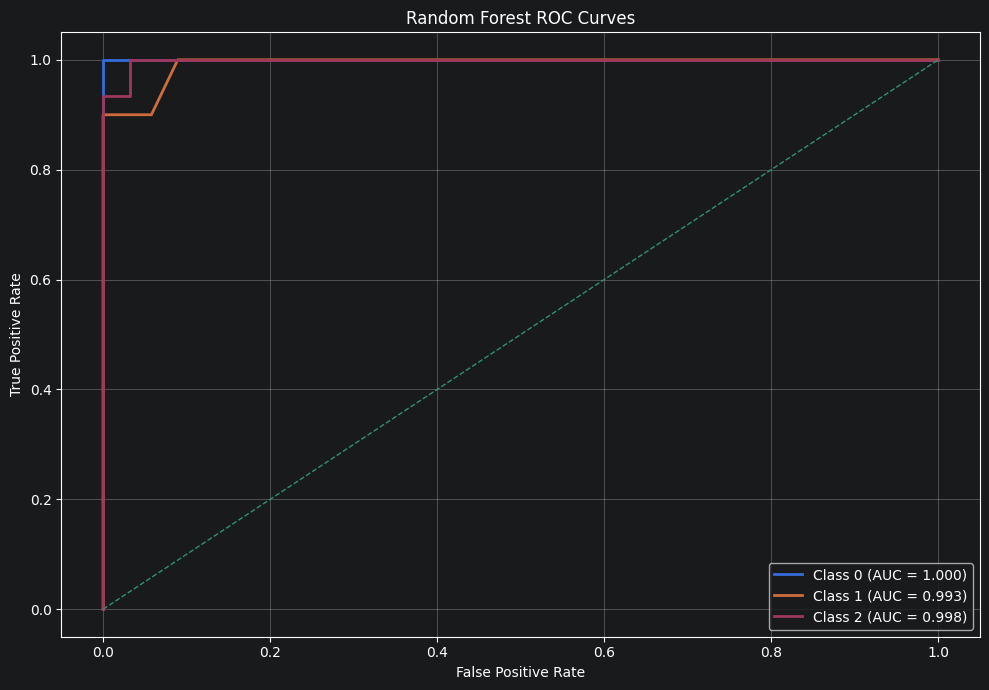

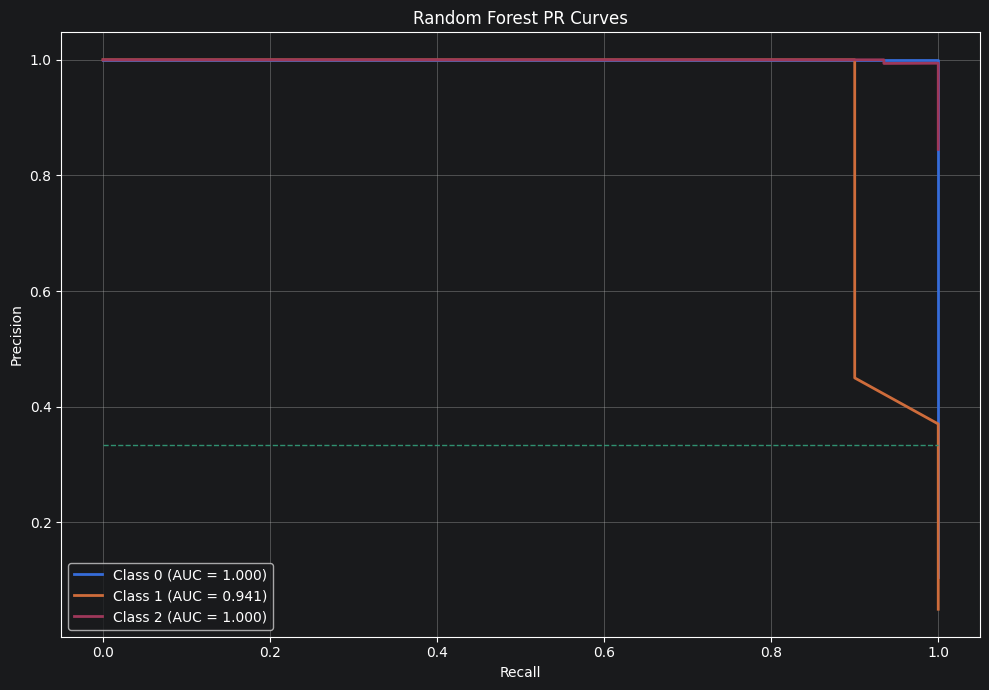

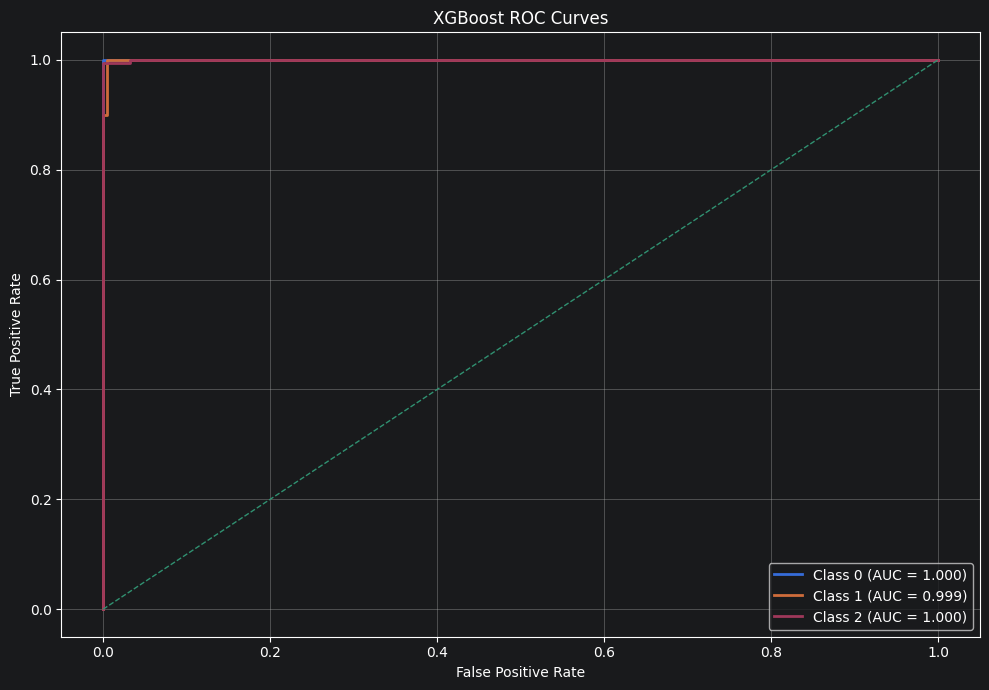

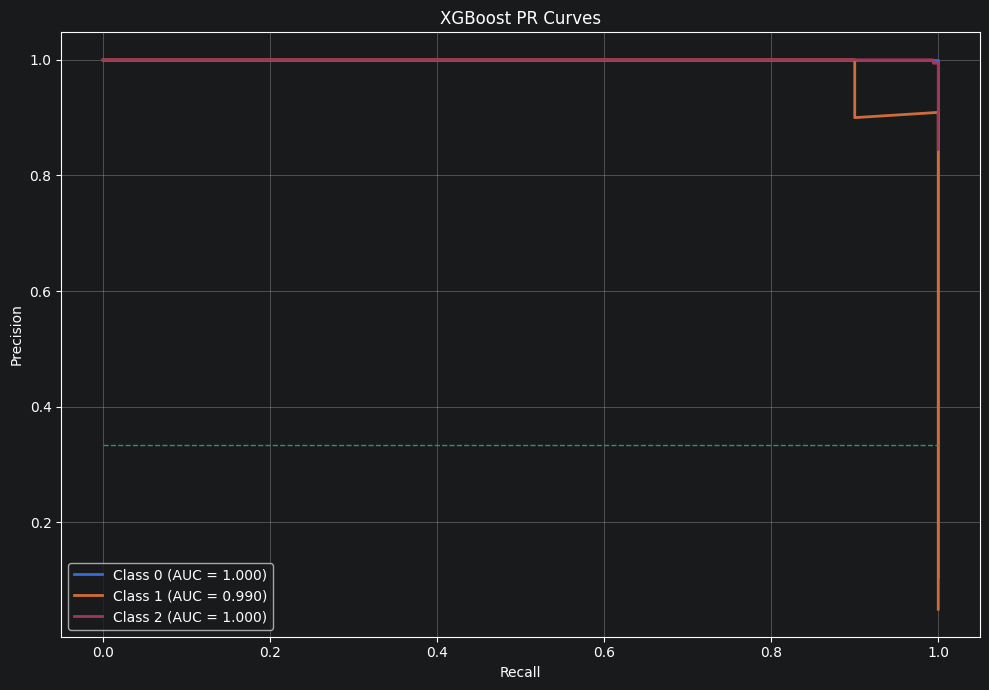

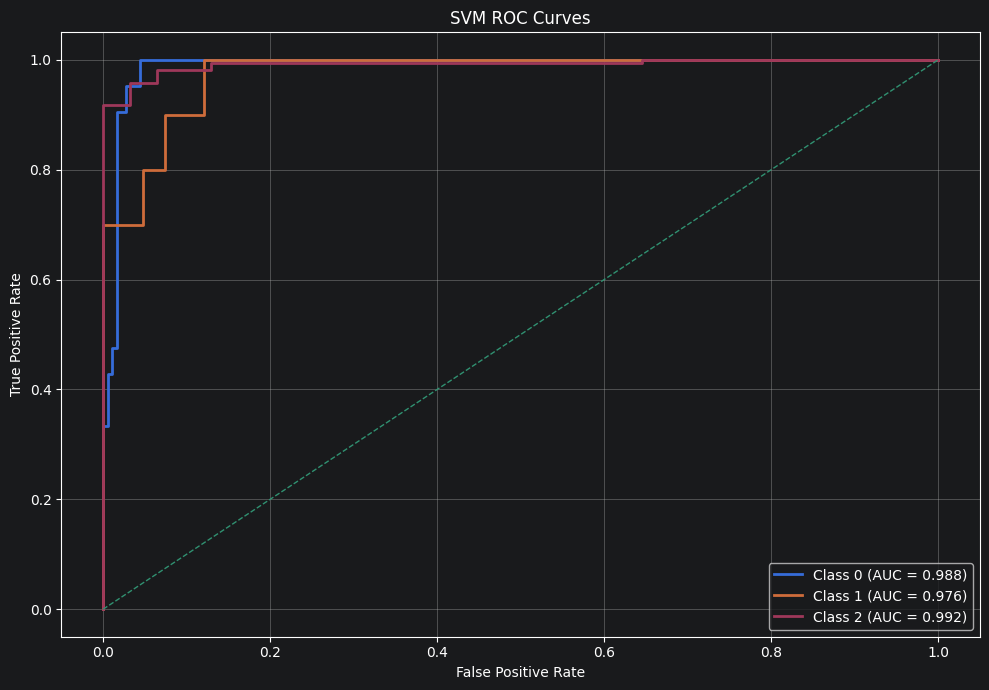

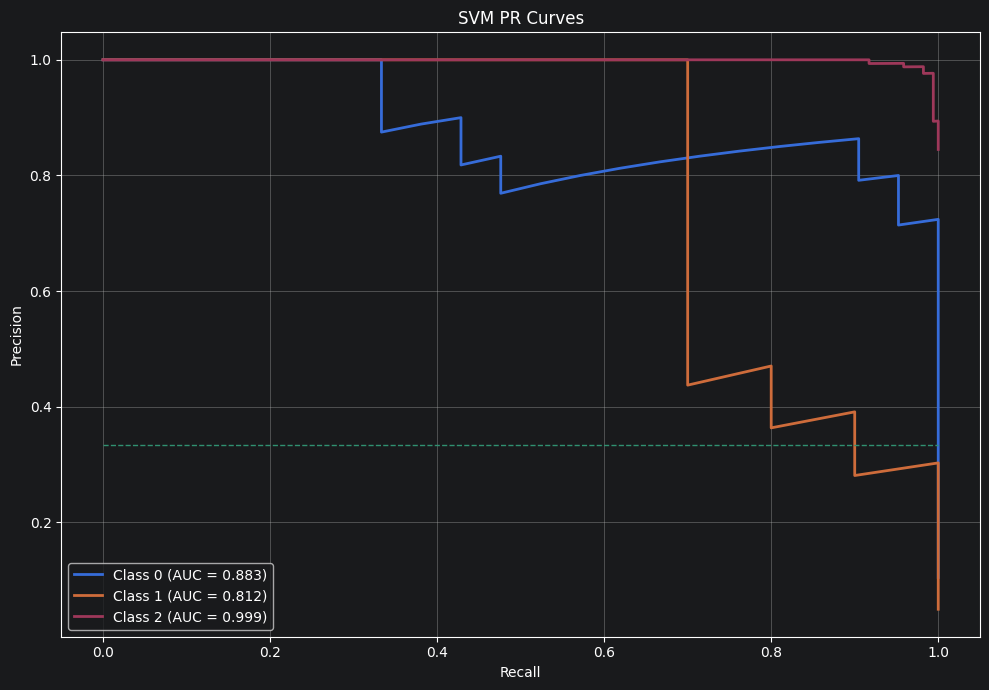

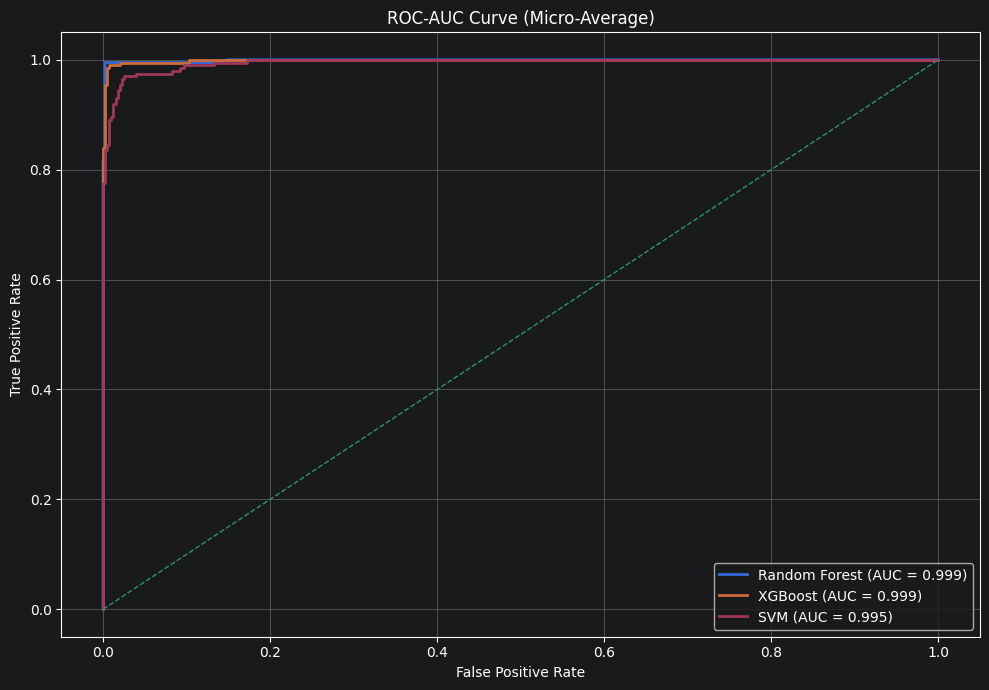

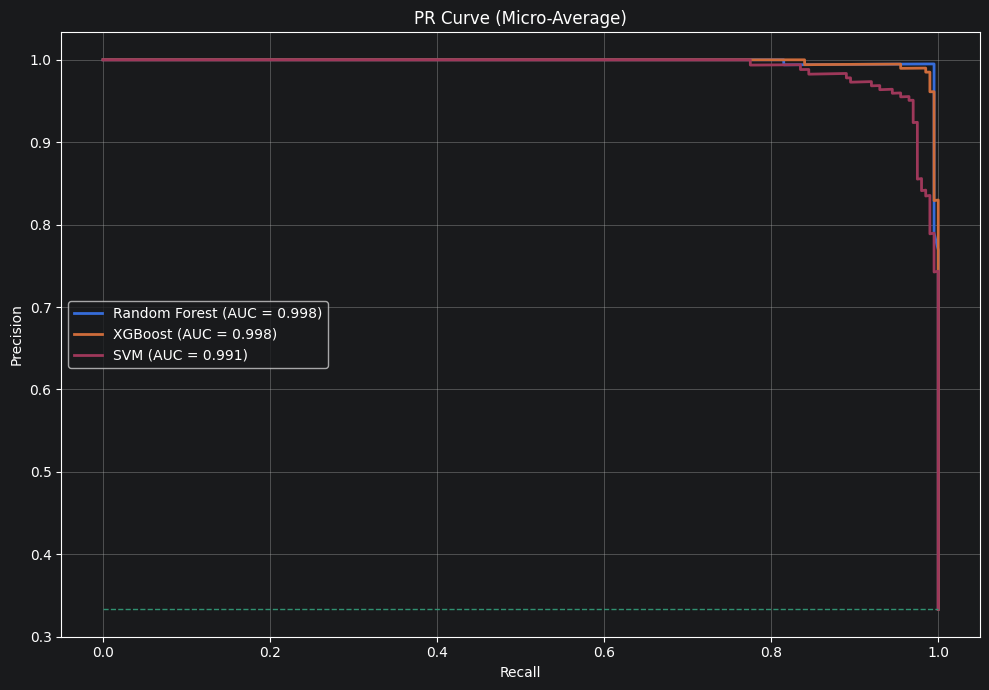

In [8]:
def safe_name(name):
    return name.lower().replace(" ", "_")


# PER-MODEL ROC AND PR (ONE-VS-REST)
for model_name, metrics in results.items():

    y_prob = metrics["probabilities"]

    # ROC PER CLASS
    plt.figure(figsize=(10, 7))
    for idx, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(
            y_test_bin[:, idx],
            y_prob[:, idx]
        )
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.title(f"{model_name} ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        os.path.join(IMAGE_PATH, f"{safe_name(model_name)}_roc_curves.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # PR PER CLASS
    plt.figure(figsize=(10, 7))
    for idx, cls in enumerate(classes):
        precision, recall, _ = precision_recall_curve(
            y_test_bin[:, idx],
            y_prob[:, idx]
        )
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, linewidth=2, label=f"Class {cls} (AUC = {pr_auc:.3f})")

    baseline = y_test_bin.mean()
    plt.plot([0, 1], [baseline, baseline], linestyle="--", linewidth=1)
    plt.title(f"{model_name} PR Curves")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(
        os.path.join(IMAGE_PATH, f"{safe_name(model_name)}_pr_curves.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


# ROC COMPARISON (MICRO-AVERAGE)
plt.figure(figsize=(10, 7))
for model_name, metrics in results.items():
    y_prob = metrics["probabilities"]

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("ROC-AUC Curve (Micro-Average)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(IMAGE_PATH, "roc_auc_curve_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# PR COMPARISON (MICRO-AVERAGE)
plt.figure(figsize=(10, 7))
for model_name, metrics in results.items():
    y_prob = metrics["probabilities"]

    precision, recall, _ = precision_recall_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, linewidth=2, label=f"{model_name} (AUC = {pr_auc:.3f})")

baseline = y_test_bin.mean()
plt.plot([0, 1], [baseline, baseline], linestyle="--", linewidth=1)
plt.title("PR Curve (Micro-Average)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    os.path.join(IMAGE_PATH, "pr_curve_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()